In [1]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tqdm import tqdm
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import gruanpy as gp
from applications.pblh_unc.methodology import *
from applications.pblh_unc.plot_profile import *

In [2]:
base = os.path.abspath(os.path.join(os.getcwd(), ".."))
pkl_path = os.path.join(base, "pblh_unc", "pkls", "gdp_2024_HKO-RS-01_2024.pkl")

with open(pkl_path, "rb") as f:
    dataset = pickle.load(f)

print("Dataset Loaded")


Dataset Loaded


In [3]:
def gdp_iterator(dataset):
    for pid, gdp in dataset.items():
        yield pid, gdp
iterator = gdp_iterator(dataset)

In [4]:
pid, gdp = next(iterator)

In [26]:
upper_bound = gp._find_upper_bound(gdp.data[['alt']], upper_bound=3500, return_value=True)
gdp.data = gdp.data[gdp.data['alt'] <= upper_bound]
data=gdp.data

where = gdp.global_attrs[gdp.global_attrs['Attribute'] == 'g.Site.Name']['Value'].values[0]
when = gdp.global_attrs[gdp.global_attrs['Attribute'] == 'g.Measurement.StartTime']['Value'].values[0]
when = when[0:10] + " " + when[11:19]

# Standard plug-in PBLH
std_pblh = gp.pblh_values(gp.apply_pblh_methods(gdp.data))

In [27]:
model, results = fit_ssm(gdp, method="powell", iterations=100)

Optimization terminated successfully.
         Current function value: 7.051816
         Iterations: 6
         Function evaluations: 821


In [28]:
results_dict = {}

# 2. Smooth variables
smooth_vars = smooth_variables(results.smoothed_state, results.smoothed_state_cov)

# 3. SSM PBLH
sm_pblh = smooth_pblh(smooth_vars)

# 4. Monte‑Carlo simulations
M = 200
simulations = simulate_ssm(model, M, seed=42)

sim_pblh_list = []

for sim in simulations:
    sim_vars = smooth_variables(sim)  # uses smoothed_state only
    sim_pblh = smooth_pblh(sim_vars)
    sim_pblh_list.append(sim_pblh)

# Convert to DataFrame (this was missing!)
df_sim = pd.DataFrame(sim_pblh_list)

# Compute uncertainty statistics
pblh_unc = {
    key: {
        "mean": df_sim[key].mean(),
        "median": df_sim[key].median(),
        "std": df_sim[key].std(),
        "2.5": df_sim[key].quantile(0.025),
        "97.5": df_sim[key].quantile(0.975),
    }
    for key in ["pm", "thv", "rh", "ri"]
}

results_dict[pid] = {
    "std_pblh": std_pblh,
    "sm_pblh": sm_pblh,
    "smooth_vars": smooth_vars,
    "sim_pblh": df_sim,
    "pblh_unc": pblh_unc,
}

#print(results_dict)

# -----------------------------
# Extract smoothed variables + uncertainties
# -----------------------------
alt_s        = smooth_vars["alt"]
alt_s_unc    = smooth_vars["alt_unc"]

thv_s        = smooth_vars["thv"]
thv_s_unc    = smooth_vars["thv_unc"]

rh_s         = smooth_vars["rh"]
rh_s_unc     = smooth_vars["rh_unc"]

u_s          = smooth_vars["u"]
u_s_unc      = smooth_vars["u_unc"]

v_s          = smooth_vars["v"]
v_s_unc      = smooth_vars["v_unc"]

# Rates of change (vertical derivatives)
alt_rc_s     = smooth_vars["alt_rc"]
alt_rc_s_unc = smooth_vars["alt_rc_unc"]

thv_rc_s     = smooth_vars["thv_rc"]
thv_rc_s_unc = smooth_vars["thv_rc_unc"]

rh_rc_s      = smooth_vars["rh_rc"]
rh_rc_s_unc  = smooth_vars["rh_rc_unc"]

u_rc_s       = smooth_vars["u_rc"]
u_rc_s_unc   = smooth_vars["u_rc_unc"]

v_rc_s       = smooth_vars["v_rc"]
v_rc_s_unc   = smooth_vars["v_rc_unc"]

# Gradients
thv_g_s      = smooth_vars["thv_grad"]
thv_g_s_unc  = smooth_vars["thv_grad_unc"]

rh_g_s       = smooth_vars["rh_grad"]
rh_g_s_unc   = smooth_vars["rh_grad_unc"]

# Richardson number
ri_s         = smooth_vars["rich"]
ri_s_unc     = smooth_vars["rich_unc"]


# -----------------------------
# Extract observed variables + uncertainties (ONLY *_uc)
# -----------------------------

alt_o = data["alt"].values.astype(float)
alt_o_unc = data["alt_uc"].values.astype(float)

temp_o = data["temp"].values.astype(float)
temp_o_unc = data["temp_uc"].values.astype(float)

press_o = data["press"].values.astype(float)
press_o_unc = data["press_uc"].values.astype(float)

wvmr_o = data["wvmr_mass"].values.astype(float) * 1e-6
wvmr_o_unc = data["wvmr_mass_uc"].values.astype(float) * 1e-6

rh_o  = data["rh"].values.astype(float)
rh_o_unc = data["rh_uc"].values.astype(float)

u_o   = data["wzon"].values.astype(float)
u_o_unc = data["wzon_uc"].values.astype(float)

v_o   = data["wmeri"].values.astype(float)
v_o_unc = data["wmeri_uc"].values.astype(float)

# Virtual potential temperature + uncertainty
thv_o = gp.virtual_potential_temperature(temp_o, press_o, wvmr_o)
thv_o_unc = gp.virtual_potential_temperature_uncertainty(
    temp_o, press_o, wvmr_o,
    temp_o_unc, press_o_unc, wvmr_o_unc
)

# Observed gradients + uncertainties
thv_g_o = gp.finite_difference_gradient(pd.Series(thv_o), pd.Series(alt_o))
thv_g_o_unc = gp.finite_difference_gradient_uncertainty(
pd.Series(thv_o),
pd.Series(alt_o),
pd.Series(thv_o_unc),
pd.Series(alt_o_unc))

rh_g_o  = gp.finite_difference_gradient(pd.Series(rh_o), pd.Series(alt_o))
rh_g_o_unc = gp.finite_difference_gradient_uncertainty(
pd.Series(rh_o),
pd.Series(alt_o),
pd.Series(rh_o_unc),
pd.Series(alt_o_unc)
)

# Observed Richardson number + uncertainty

ri_o = gp.bulk_richardson_number(thv_o[0], thv_o, alt_o, u_o, v_o)

ri_o_unc = gp.bulk_richardson_number_uncertainty_np(
thv_o[0], thv_o, alt_o, u_o, v_o,
thv_o_unc[0], thv_o_unc, alt_o_unc, u_o_unc, v_o_unc
)

pblh_info = {
"pm": {
    "value":  std_pblh[0],
    "median": pblh_unc["pm"]["median"],
    "low":    pblh_unc["pm"]["2.5"],
    "high":   pblh_unc["pm"]["97.5"],
},

"thv": {
    "value":  std_pblh[1],
    "median": pblh_unc["thv"]["median"],
    "low":    pblh_unc["thv"]["2.5"],
    "high":   pblh_unc["thv"]["97.5"],
},

"rh": {
    "value":  std_pblh[2],
    "median": pblh_unc["rh"]["median"],
    "low":    pblh_unc["rh"]["2.5"],
    "high":   pblh_unc["rh"]["97.5"],
},

"ri": {
    "value":  std_pblh[3],
    "median": pblh_unc["ri"]["median"],
    "low":    pblh_unc["ri"]["2.5"],
    "high":   pblh_unc["ri"]["97.5"],
}}

# Add MC samples to pblh_info
pblh_info["pm"]["samples"]  = df_sim["pm"].values
pblh_info["thv"]["samples"] = df_sim["thv"].values
pblh_info["rh"]["samples"]  = df_sim["rh"].values
pblh_info["ri"]["samples"]  = df_sim["ri"].values

where = gdp.global_attrs[gdp.global_attrs['Attribute'] == 'g.Site.Name']['Value'].values[0] # location
when = gdp.global_attrs[gdp.global_attrs['Attribute'] == 'g.Measurement.StartTime']['Value'].values[0] # time
when=when[0:10]
tod=gdp.global_attrs[gdp.global_attrs['Attribute'] == "g.Measurement.TimeOfDay"]['Value'].values[0] # time


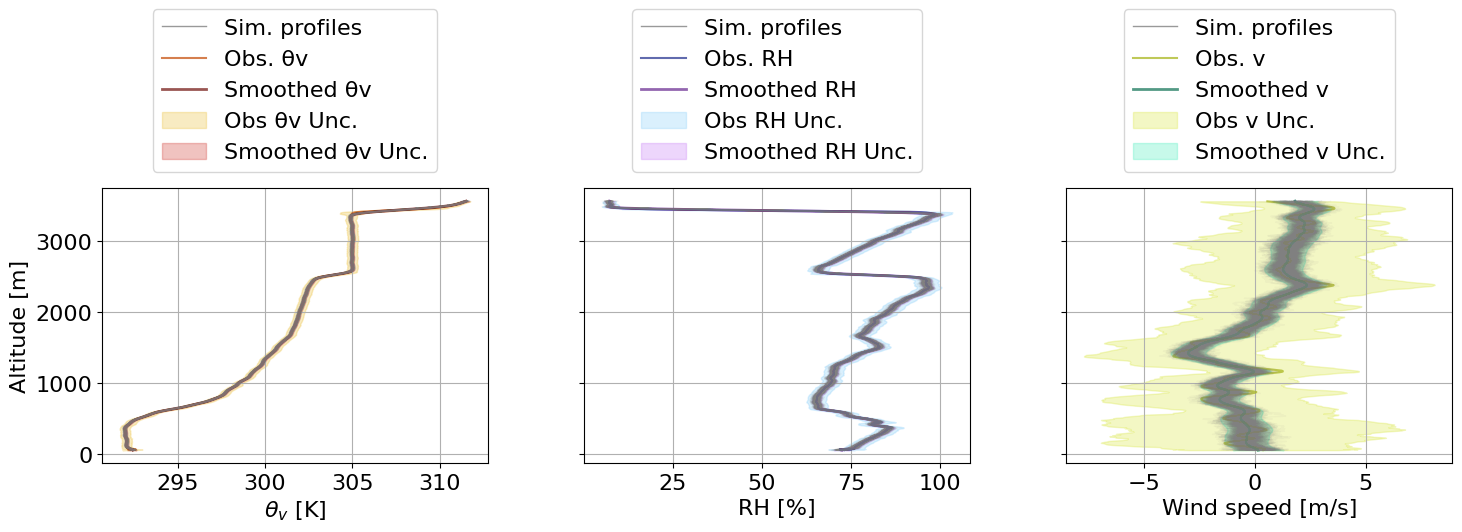

In [30]:
plot_ssm_diagnostics_short(
            pid, where, when, tod,
            alt_o, thv_o, rh_o, u_o, v_o,
            thv_o_unc, rh_o_unc, u_o_unc, v_o_unc,
            alt_s, thv_s, rh_s, u_s, v_s,
            thv_s_unc, rh_s_unc, u_s_unc, v_s_unc,
            simulations,
            None,#pblh_info,
            map_labels_to_colors,
            scatter_obs=False)

https://www.statsmodels.org/stable/statespace.html#output-and-postestimation-methods-and-attributes

In [7]:
# - Print a table summarizing estimation results
print(results.summary())


                                 Statespace Model Results                                 
Dep. Variable:     ['y1', 'y2', 'y3', 'y4', 'y5']   No. Observations:                  643
Model:             PreTransformedLocalLinearTrend   Log Likelihood               -4534.318
Date:                            Mon, 27 Jul 2026   AIC                           9088.636
Time:                                    11:17:22   BIC                           9133.141
Sample:                                         0   HQIC                          9105.919
                                            - 643                                         
Covariance Type:                              opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
alt_sigma2.level  8.968e-11      0.778   1.15e-10      1.000      -1.525       1.525
alt_sigma2.trend 

In [8]:
# - Print only the estimated parameters
print(results.params)

[8.96799621e-11 6.21727682e-02 3.36889935e-11 2.55439788e-04
 9.59419068e-11 1.76114233e-01 1.78596913e-14 3.24472406e-04
 2.99587156e-02 4.75813925e-10]


In [15]:
print(results.bse)

[7.78282997e-01 2.49038599e-02 1.40403350e-03 5.81287924e-05
 1.69008183e-01 1.39471114e-02 6.84575750e-02 4.33753129e-04
 3.20735384e-02 4.01920320e-06]


In [16]:
print(results.pvalues)

[1.00000000e+00 1.25421664e-02 9.99999981e-01 1.11091238e-05
 1.00000000e+00 1.49331265e-36 1.00000000e+00 4.54425302e-01
 3.50271233e-01 9.99905542e-01]


In [17]:
print(results.llf)

-4534.317986540393


In [18]:
print(results.sse, results.mse, results.mae)

101259.6887050989 157.4800757466546 0.747153208544351


In [20]:
print(results.aic, results.aicc, results.bic)#, results.hquc)

9088.635973080785 9088.989670829982 9133.140677302226


In [21]:
print(results.fittedvalues)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 6.13795658e+01  2.92188528e+02  7.30360010e+01 -5.87618377e-01
   3.80097668e-01]
 [ 6.95661637e+01  2.92660593e+02  7.09194658e+01 -6.67197016e-01
   4.23278965e-01]
 ...
 [ 3.54922809e+03  3.11481708e+02  6.81018231e+00  8.23248689e+00
   2.27801511e+00]
 [ 3.55533279e+03  3.11507745e+02  6.86184705e+00  8.41912531e+00
   2.13161357e+00]
 [ 3.56112750e+03  3.11539635e+02  7.00190394e+00  8.60080727e+00
   1.98045375e+00]]


In [22]:
print(results.resid)

[[ 6.13809662e+01  2.92188538e+02  7.30361710e+01 -5.87624431e-01
   3.80098730e-01]
 [ 4.09342619e+00  2.36032150e-01 -1.05827116e+00 -3.97899487e-02
   2.15907589e-02]
 [-2.29667824e+00 -1.38772606e-01  9.87737855e-01 -1.23981567e-02
  -1.44620914e-02]
 ...
 [-5.70135172e-01 -1.50958770e-01  2.15725688e-01  4.13180182e-01
  -1.43918917e+00]
 [-1.39090017e+00 -1.10893943e-01  2.43890634e-01  3.53595023e-01
  -1.43599894e+00]
 [-3.29742321e+00 -9.13318545e-02  2.73177221e-01  2.71019856e-01
  -1.41317226e+00]]


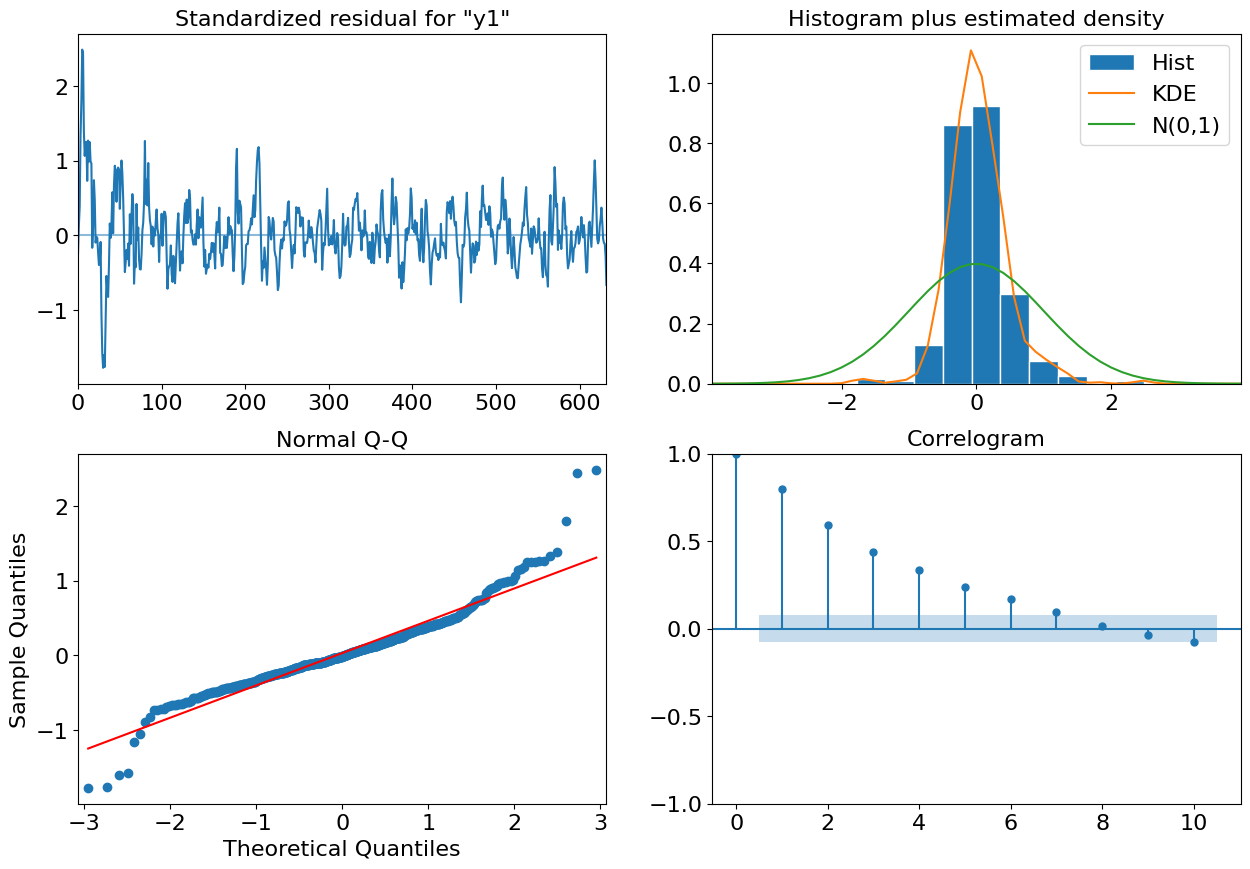

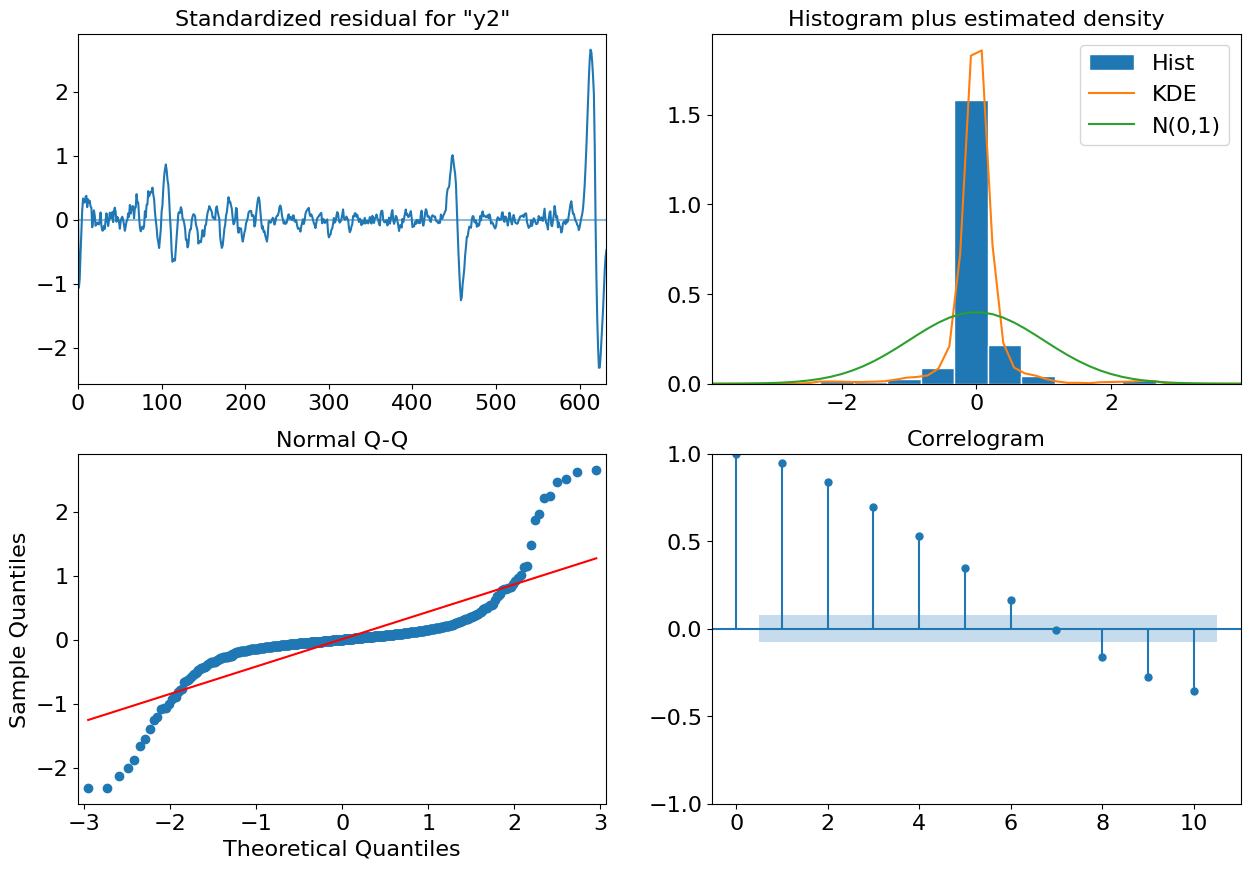

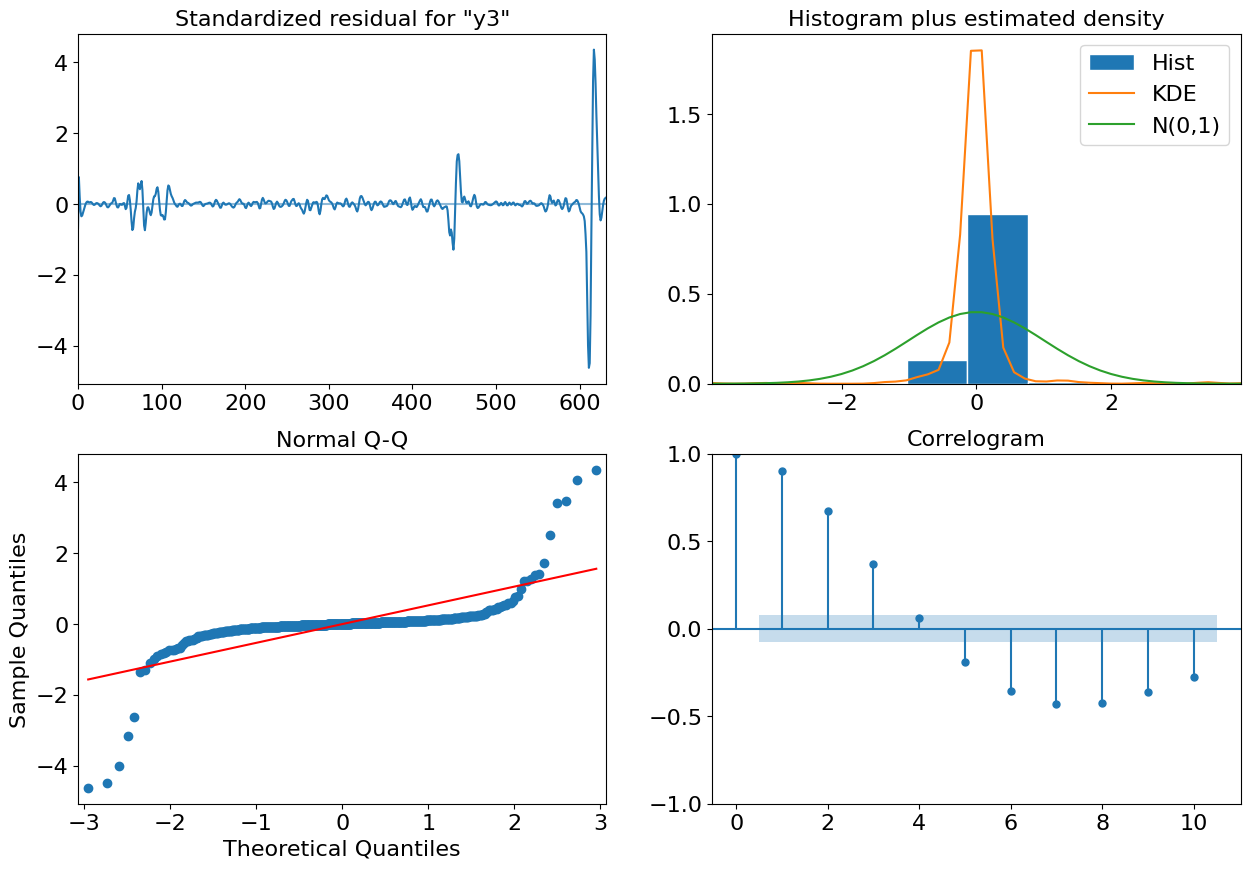

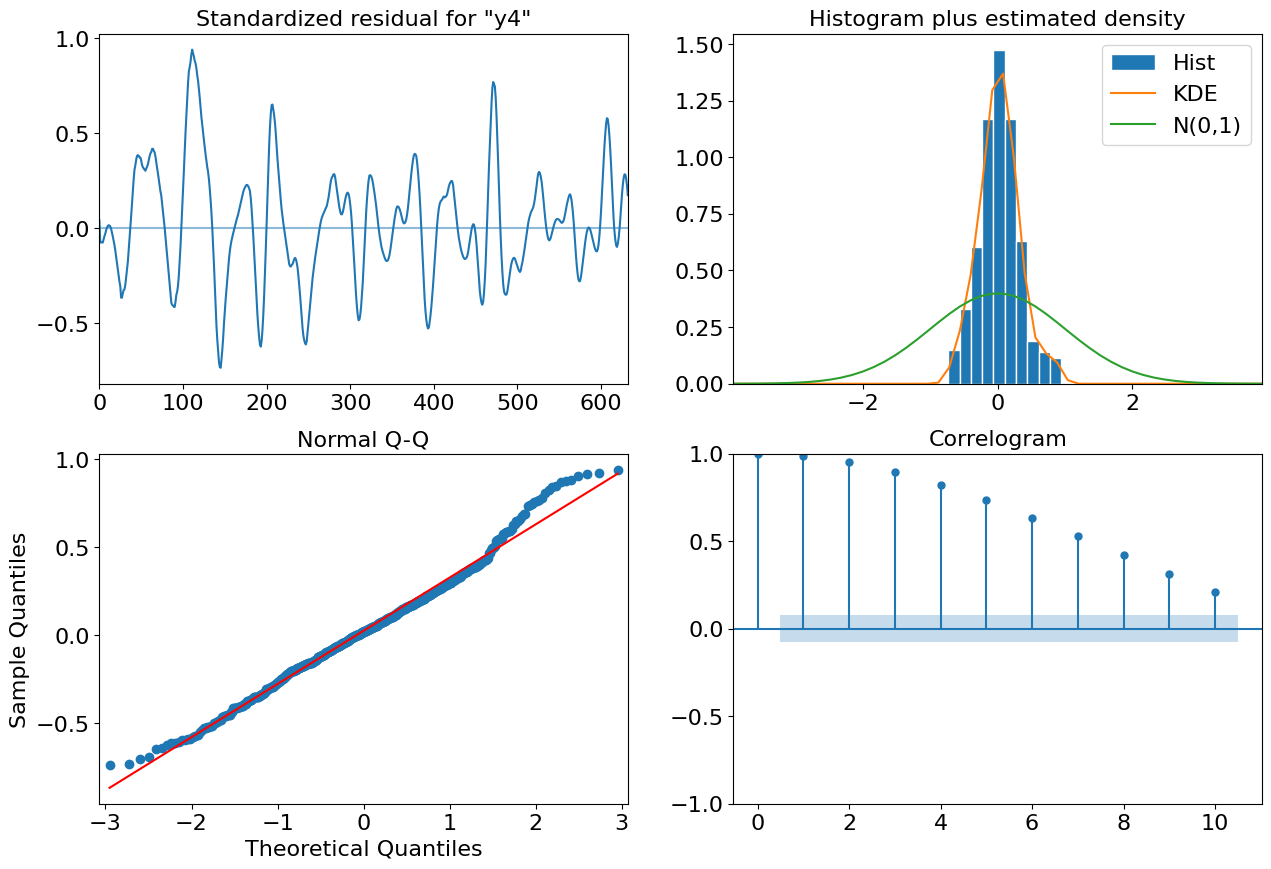

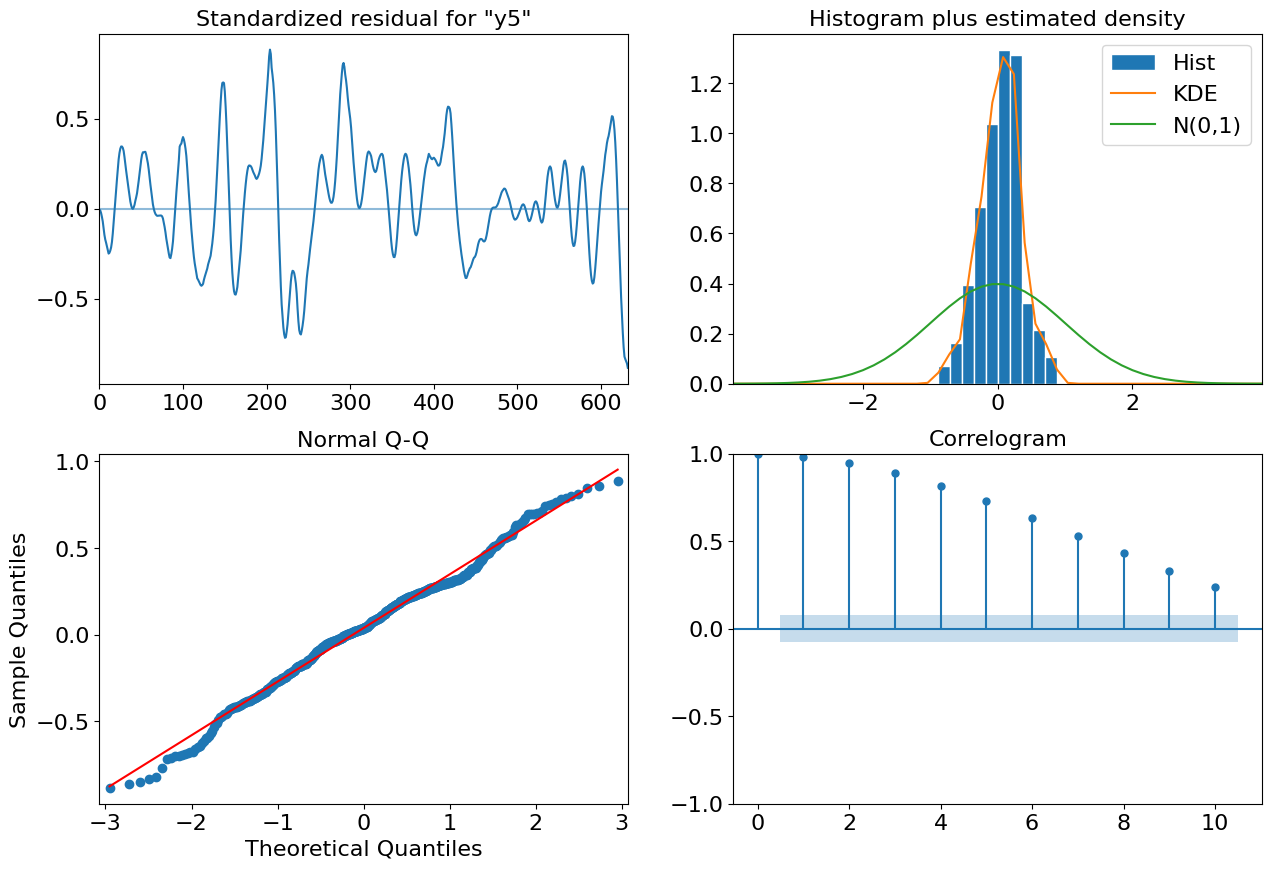

In [14]:
# - Create diagnostic figures based on standardized residuals:
#   (1) time series graph
#   (2) histogram
#   (3) Q-Q plot
#   (4) correlogram
for var in range(5):
    fig=results.plot_diagnostics(variable=var)
    fig.set_size_inches(15,10)
    plt.show(block=True)

In [13]:
# - Examine diagnostic hypothesis tests
# Jarque-Bera: [test_statistic, pvalue, skewness, kurtosis]
print(results.test_normality(method='jarquebera'))

[[ 6.07409222e+002  1.26696119e-132  7.05091434e-001  7.58705982e+000]
 [ 6.75200466e+003  0.00000000e+000  8.18942431e-001  1.89159514e+001]
 [ 4.78140310e+004  0.00000000e+000 -5.05342756e-001  4.55656290e+001]
 [ 1.30660694e+001  1.45458494e-003  2.95100743e-001  3.38348168e+000]
 [ 4.28260261e+000  1.17501838e-001 -1.51646449e-001  3.26530544e+000]]


In [ ]:
# Goldfeld-Quandt type test: [test_statistic, pvalue]
print(results.test_heteroskedasticity(method='breakvar'))

[[3.00279787e-01 2.17818663e-17]
 [6.30813551e+00 3.31159191e-36]
 [1.74289762e+01 1.73542867e-74]
 [3.74394296e-01 2.72697621e-12]
 [6.37244813e-01 1.13332072e-03]]


In [ ]:
# Ljung-Box test: [test_statistic, pvalue] for each lag
print(results.test_serial_correlation(method='ljungbox'))

[[[4.06102964e+002 6.31771901e+002 7.54575907e+002 8.27580862e+002
   8.63635018e+002 8.82417359e+002 8.88350107e+002 8.88502831e+002
   8.89466941e+002 8.93069103e+002]
  [2.58476355e-090 6.49343879e-138 3.07106964e-163 8.14568818e-178
   1.97178945e-184 2.37537365e-187 1.57391132e-187 1.70503344e-186
   1.15036708e-185 1.97522403e-185]]

 [[5.71188450e+002 1.02176276e+003 1.33208256e+003 1.51044781e+003
   1.58641928e+003 1.60328050e+003 1.60334418e+003 1.61959894e+003
   1.66818304e+003 1.74946305e+003]
  [3.09597425e-126 1.33978721e-222 1.60871706e-288 0.00000000e+000
   0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
   0.00000000e+000 0.00000000e+000]]

 [[5.19311801e+002 8.07932094e+002 8.94346459e+002 8.96730341e+002
   9.19713381e+002 1.00071858e+003 1.11951086e+003 1.23522788e+003
   1.32069857e+003 1.37048590e+003]
  [5.97405042e-115 3.62889912e-176 1.49043056e-193 8.51294622e-193
   1.44042337e-196 6.25158979e-213 1.78511207e-237 2.34307168e-261
   1.0466913